
# LUPI 1D visualization: lower / student / oracle / upper

One column, four rows, in the order requested: **lower bound** (A_ctx alone),
**student** (LUPIPFN, infers alignment), **oracle** (LUPIPFN, `T(x*)` given),
**upper bound** ([A_ctx ; B_inA] pooled). Each row overlays: context data,
the true (noiseless) function on A's own quantile scale, the model's
posterior mean, and the full predictive density as a background heatmap.

**Caveat on rows 1 and 4 (lower/upper):** these reuse the existing
`pfn_variable_dim5_long` checkpoint (`ppfn.model.pfn.pfn.PFN`), which was
trained on `ppfn.prior.bnn.BNNPrior` -- a *different* generative prior than
`ppfn.prior.lupi` (no warps, no A/B clouds, family-level not per-task
quantile normalization). The interface is compatible (variable context size,
variable x_dim up to 5, [0,1]-bounded `BarDistribution` output matches LUPI's
own quantile-normalized target scale), so it runs as a drop-in and gives an
immediately-available directional signal ("does pooling B_inA sharpen the
prediction at all, even under an unrelated pretrained PFN?"). It is **not**
a prior-matched lower/upper bound in the rigorous NLL sense -- that's what
`ppfn.model.baselines.lupi_bounds_pfn.BoundsPFN` (trained directly on this
prior, `docs/labbook/2026-09-15-lupi-bounds-and-stratified-diagnostics.md`)
is for; swap its checkpoint in here once that run finishes, same code path.


In [1]:

import dataclasses

import matplotlib.pyplot as plt
import numpy as np
import torch

from ppfn.model.lupi.model import LUPIPFN
from ppfn.model.pfn.pfn import PFN
from ppfn.prior.lupi.dataset import D_MAX, collate_lupi_batch
from ppfn.prior.lupi.sampler import sample_pair

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:

# --- checkpoints ---
LUPI_CKPT = "/home/ruhkopf/PycharmProjects/Meta_FTPFN_lupi/models/01-pretraining-lupi-baseline/best_01-pretraining-lupi-baseline.pt"
REUSED_PFN_CKPT = "/home/ruhkopf/PycharmProjects/Meta_FTPFN/models/pfn_variable_dim5_long.pt"

lupi_model = LUPIPFN(
    d_model=256, n_heads=8, n_layers_enc_b=3, n_layers_align=6,
    d_ff=512, n_bins_predictive=64, dropout=0.0,
).to(device)
lupi_ckpt = torch.load(LUPI_CKPT, map_location=device, weights_only=False)
lupi_model.load_state_dict(lupi_ckpt["model_state_dict"])
lupi_model.eval()
print("LUPIPFN checkpoint: epoch", lupi_ckpt.get("epoch"), "best_score", lupi_ckpt.get("best_score"))

# ppfn.trainer.pfn_trainer.PFNTrainer's own checkpoint schema -- see
# .claude/rules/checkpoints.md: "model_state", not "model_state_dict".
reused_pfn = PFN(max_x_dim=D_MAX, d_model=256, n_heads=8, n_layers=6, d_ff=512, n_bins=128).to(device)
reused_ckpt = torch.load(REUSED_PFN_CKPT, map_location=device, weights_only=False)
reused_pfn.load_state_dict(reused_ckpt["model_state"])
reused_pfn.eval()
print("reused PFN checkpoint step:", reused_ckpt.get("history", {}).get("step", [None])[-1]
      if isinstance(reused_ckpt.get("history"), dict) else None)


LUPIPFN checkpoint: epoch 99 best_score -2.3839547634124756
reused PFN checkpoint step: 199999


## Draw one d=1 pair, at a genuinely non-trivial relative warp (rho), and build the plotting grid

In [3]:

SEED = 7
RHO = 0.6  # genuinely non-trivial relative warp; try 0.0 for the identity sanity check
N_GRID = 300

rng = np.random.default_rng(SEED)
pair, internals = sample_pair(
    rng, rho=RHO, d=1, n_a_range=(10, 20), n_b_range=(60, 120), n_qry_range=(8, 8),
    return_internals=True,
)
d_real = pair.d
print(f"drawn pair: d={d_real} rho={pair.rho:.2f} beta={pair.beta:.2f} n_a={pair.x_a_ctx.shape[0]} n_b={pair.x_b.shape[0]}")

item = {
    "d_real": pair.d, "rho": np.float32(pair.rho), "beta": np.float32(pair.beta),
    "enc_x": pair.x_b.astype(np.float32), "enc_z": pair.z_b.astype(np.float32),
    "enc_x_inA": pair.x_b_inA.astype(np.float32),
    "dec_ctx_x": pair.x_a_ctx.astype(np.float32), "dec_ctx_z": pair.z_a_ctx.astype(np.float32),
    "dec_ctx_oracle_bpos": pair.oracle_bpos_a_ctx.astype(np.float32),
    "dec_qry_x": pair.x_a_qry.astype(np.float32), "dec_qry_z": pair.z_a_qry.astype(np.float32),
    "dec_qry_oracle_bpos": pair.oracle_bpos_a_qry.astype(np.float32),
    "dec_qry_source": pair.qry_source,
    "region_type": pair.meta["region_type"], "volume_fraction": pair.meta["volume_fraction"],
}
batch = collate_lupi_batch([item])
batch = dataclasses.replace(batch, **{
    f.name: (getattr(batch, f.name).to(device) if isinstance(getattr(batch, f.name), torch.Tensor) else getattr(batch, f.name))
    for f in dataclasses.fields(batch)
})

# Dense z-grid -> x-grid (A's frame) + oracle B-frame position + true target,
# all via forward-only warp evaluation (no inversion) -- see
# ppfn.prior.lupi.sampler.LUPIPairInternals's docstring.
z_grid = np.linspace(0.0, 1.0, N_GRID)[:, None]
x_grid_a = internals.to_a(z_grid).astype(np.float32)
oracle_bpos_grid = internals.to_b(z_grid).astype(np.float32)
true_z_grid = internals.true_z_a(z_grid).astype(np.float32)
grid_order = np.argsort(x_grid_a[:, 0])  # to_a needn't be monotone-sorted in x already


def pad_to_dmax(x_np):
    n = x_np.shape[0]
    scaled = x_np * (D_MAX / d_real)
    return np.concatenate([scaled, np.zeros((n, D_MAX - d_real), dtype=np.float32)], axis=-1)


x_grid_a_t = torch.from_numpy(pad_to_dmax(x_grid_a)).unsqueeze(0).to(device)
oracle_bpos_grid_t = torch.from_numpy(pad_to_dmax(oracle_bpos_grid)).unsqueeze(0).to(device)


drawn pair: d=1 rho=0.60 beta=1.34 n_a=19 n_b=93


## Run all four models on the shared grid

In [4]:

grid_batch = dataclasses.replace(
    batch,
    dec_qry_x=x_grid_a_t,
    dec_qry_oracle_bpos=oracle_bpos_grid_t,
    dec_qry_mask=torch.ones(1, N_GRID, dtype=torch.bool, device=device),
)

with torch.no_grad():
    b_enc = lupi_model.encode_b(grid_batch)
    out_student = lupi_model.align(grid_batch, b_enc, mode="student")
    out_oracle = lupi_model.align(grid_batch, b_enc, mode="oracle")

    n_features_all = torch.full((1,), D_MAX, dtype=torch.long, device=device)
    logits_lower = reused_pfn(
        x_train=batch.dec_ctx_x, y_train=batch.dec_ctx_z, x_test=x_grid_a_t,
        n_features=n_features_all,
    )
    pooled_x = torch.cat([batch.dec_ctx_x, batch.enc_x_inA], dim=1)
    pooled_y = torch.cat([batch.dec_ctx_z, batch.enc_z], dim=1)
    logits_upper = reused_pfn(
        x_train=pooled_x, y_train=pooled_y, x_test=x_grid_a_t,
        n_features=n_features_all,
    )

rows = [
    ("1. Lower bound: A_ctx alone  (off-the-shelf BNNPrior-PFN)", logits_lower, reused_pfn.bar_dist, False),
    ("2. Student: A,B  (LUPIPFN, infers alignment)", out_student["predictive_logits"], lupi_model.bar_dist, True),
    ("3. Oracle: A,B  (LUPIPFN, T(x*) given)", out_oracle["predictive_logits"], lupi_model.bar_dist, True),
    ("4. Upper bound: [A_ctx ; B_inA] pooled  (off-the-shelf BNNPrior-PFN)", logits_upper, reused_pfn.bar_dist, False),
]
for name, logits, bar_dist, _ in rows:
    nll = bar_dist(logits, torch.from_numpy(true_z_grid).unsqueeze(0).to(device))
    print(f"{name:55s} mean NLL vs. true function on grid: {nll.mean().item():.4f}")


1. Lower bound: A_ctx alone  (off-the-shelf BNNPrior-PFN) mean NLL vs. true function on grid: -1.1367
2. Student: A,B  (LUPIPFN, infers alignment)            mean NLL vs. true function on grid: -3.4885
3. Oracle: A,B  (LUPIPFN, T(x*) given)                  mean NLL vs. true function on grid: -3.4968
4. Upper bound: [A_ctx ; B_inA] pooled  (off-the-shelf BNNPrior-PFN) mean NLL vs. true function on grid: -1.5886


## Plot -- one column, four rows, each: data + true function + posterior mean + predictive-density heatmap

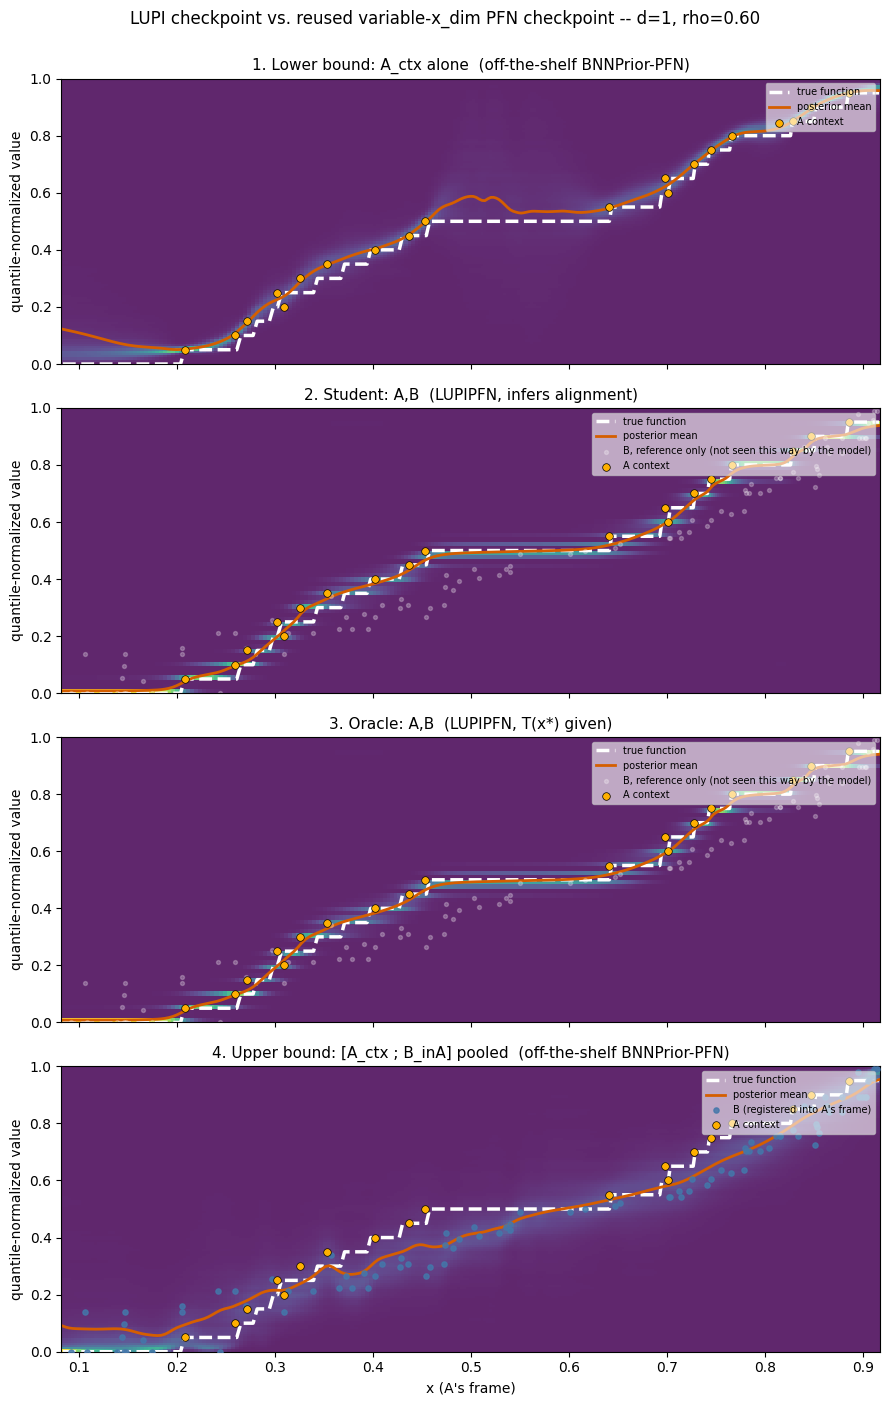

In [5]:

fig, axes = plt.subplots(4, 1, figsize=(9, 14), sharex=True)

x_a_ctx_np = pair.x_a_ctx[:, 0]
z_a_ctx_np = pair.z_a_ctx
x_b_inA_np = pair.x_b_inA[:, 0]
z_b_np = pair.z_b
x_grid_sorted = x_grid_a[grid_order, 0]
true_z_sorted = true_z_grid[grid_order]

for ax, (name, logits, bar_dist, show_b_faint) in zip(axes, rows):
    probs = torch.softmax(logits[0], dim=-1).cpu().numpy()  # [N_GRID, n_bins]
    bin_centers = (bar_dist.borders[:-1] + bar_dist.bucket_widths / 2).cpu().numpy()
    density = (probs / bar_dist.bucket_widths.cpu().numpy()[None, :])[grid_order].T  # [n_bins, N_GRID]

    ax.pcolormesh(
        x_grid_sorted, bin_centers, density, shading="auto", cmap="viridis", alpha=0.85,
    )
    mean_pred = bar_dist.mean(logits)[0].cpu().numpy()[grid_order]
    ax.plot(x_grid_sorted, true_z_sorted, color="white", lw=2.5, ls="--", label="true function")
    ax.plot(x_grid_sorted, mean_pred, color="#D55E00", lw=2, label="posterior mean")

    if name.startswith("4."):
        ax.scatter(x_b_inA_np, z_b_np, s=14, color="#4477AA", alpha=0.85, zorder=3, label="B (registered into A's frame)")
    elif show_b_faint:
        ax.scatter(x_b_inA_np, z_b_np, s=8, color="white", alpha=0.25, zorder=2, label="B, reference only (not seen this way by the model)")
    ax.scatter(x_a_ctx_np, z_a_ctx_np, s=30, color="#FFB000", edgecolor="black", linewidth=0.5, zorder=4, label="A context")

    ax.set_ylim(0, 1)
    ax.set_ylabel("quantile-normalized value")
    ax.set_title(name, fontsize=11)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.6)

axes[-1].set_xlabel("x (A's frame)")
fig.suptitle(f"LUPI checkpoint vs. reused variable-x_dim PFN checkpoint -- d=1, rho={pair.rho:.2f}", y=1.0)
fig.tight_layout()
fig.savefig("/home/ruhkopf/PycharmProjects/Meta_FTPFN_lupi/logs/lupi_1d_visualization.png", dpi=140, bbox_inches="tight")
plt.show()
